In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
data = pd.read_csv("Mall_Customers.csv")
data.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [6]:
from sklearn.preprocessing import LabelEncoder
l = LabelEncoder()
data['Genre'] = l.fit_transform(data['Genre'])
data.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


In [10]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [11]:
#annual income vs spending score
X1 = data[['Annual Income (k$)', 'Spending Score (1-100)']]
X1_scaled = scaler.fit_transform(X1)
X1 = pd.DataFrame(X1_scaled, columns=X1.columns)
X1.head()

,Annual Income (k$),Spending Score (1-100)
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


In [47]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
kmeans.fit(X1)
X1['Clusters'] = kmeans.labels_
X1.head()

,Annual Income (k$),Spending Score (1-100),Clusters
0,-1.738999,-0.434801,4
1,-1.738999,1.195704,2
2,-1.700830,-1.715913,4
3,-1.700830,1.040418,2
4,-1.662660,-0.395980,4


In [48]:
kmeans.cluster_centers_

array([[-2.00912566e-01, -2.64561747e-02, -4.44089210e-16],
       [ 1.05500302e+00, -1.28443907e+00,  3.00000000e+00],
       [-1.32954532e+00,  1.13217788e+00,  4.00000000e+00],
       [ 9.91583048e-01,  1.23950275e+00,  1.00000000e+00],
       [-1.30751869e+00, -1.13696536e+00,  2.00000000e+00]])

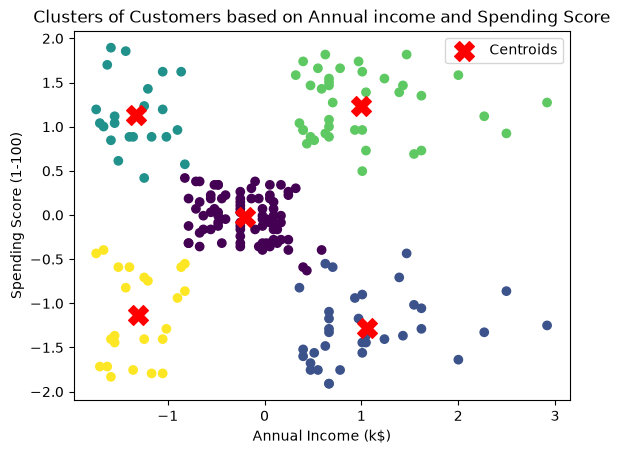

In [31]:
import matplotlib.pyplot as plt
# visualize clusters with there centeroid
plt.scatter(X1.iloc[:, 0],X1.iloc[:, 1], c=kmeans.labels_, cmap="viridis")
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker="X",
    s=200,
    color="red",
    label="Centroids"
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Clusters of Customers based on Annual income and Spending Score")
plt.legend()
plt.show()